In [30]:

from langgraph.graph import END ,START,StateGraph
from langgraph.graph.message import MessagesState
import os 
from dotenv import load_dotenv 
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import display ,Image
from langchain_groq import ChatGroq
from langchain_core.tools import tool 




In [31]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3.6-27b")


In [32]:


@tool 
def get_weather(city:str)->str:
    """analysie the sentense and return back the city if the word cold present"""
    return  f"the weather is cold and temp is {city } 49 f "


@tool 
def get_weather_station():
    """the are returning the station name """
    return  f" the station name is the ALBERT COLD STATION"

@tool 
def graphdb(query:str)->str:
    """the are returning  the cypher query  """
    return  f" creater cypher qurey for the normal act ={query} is {llm.invoke(query).content} "

tools=[get_weather_station,get_weather,graphdb]
 




In [33]:
t_llm=llm.bind_tools(tools)

In [34]:
def reactbot(state:MessagesState):
    response=t_llm.invoke(state["messages"])
    return {"message":[response]}


tool_node=ToolNode(tools)


In [35]:
workflow = StateGraph(MessagesState)

workflow.add_node("react_bot", reactbot)
# 1. Change the name here from "tool_node" to "tools"
workflow.add_node("tools", tool_node) 


In [36]:
workflow.add_edge(START,"react_bot")
workflow.add_conditional_edges("react_bot",tools_condition)
workflow.add_edge("tools","react_bot")

In [38]:
app=workflow.compile()

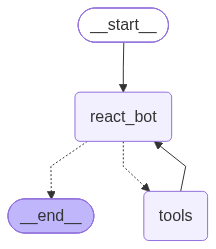

In [40]:
display(Image(app.get_graph().draw_mermaid_png()))